# 4. Evaluation 
### 4.1 Processed Data without thresholds for Air-Quality
### 4.2 Processed Data with thresholds for Air-Quality

In [8]:
import pandas as pd
import pickle

# Load your dataset
df: pd.DataFrame = pd.read_csv('../data/AirQualityUCIClustered.csv')
with open('../data/features.pkl', 'rb') as file:
    features: list = pickle.load(file)

df_th: pd.DataFrame = pd.read_csv('../data/AirQualityUCIClusteredWithThresholds.csv')
with open('../data/features_with_thresholds.pkl', 'rb') as file:
    features_th: list = pickle.load(file)

In [9]:
# 4.1 Group by clusters and compute mean of features
cluster_summary = df.groupby('Cluster')[features].mean().round(2)
print("\n4.1 Cluster Summary:")
print(cluster_summary)

# Count of records per cluster
print("\nCluster Counts:")
print(df['Cluster'].value_counts())


4.1 Cluster Summary:
         CO(GT)  C6H6(GT)  NO2(GT)  PT08.S5(O3)  Month  HourOfDay      T  \
Cluster                                                                    
0          3.86     19.12   155.98      1541.78   6.56      14.10  16.32   
1          1.21      4.67    81.41       793.02   6.11       5.27  14.10   
2          1.82      9.34   104.92       905.46   6.33      16.19  24.09   

            RH  
Cluster         
0        53.91  
1        58.86  
2        35.31  

Cluster Counts:
Cluster
1    3544
2    3318
0    2495
Name: count, dtype: int64


| Cluster | Label                                      | CO(GT) | C6H6(GT) | NO2(GT) | PT08.S5(O3) | Hour | Temp (°C) | RH (%) | Key Characteristics |
|--------|--------------------------------------------|--------|----------|---------|-------------|------|-----------|--------|---------------------|
| 0      | High Pollution / Peak Activity             | 3.86   | 19.12    | 155.98  | 1541.78     | 14.10| 16.32     | 53.91  | Highest pollution levels, afternoon peak, moderate temp & humidity |
| 1      | Low Pollution / Early Morning Clean Air    | 1.21   | 4.67     | 81.41   | 793.02      | 5.27 | 14.10     | 58.86  | Cleanest air, early morning, coolest and most humid conditions |
| 2      | Moderate Pollution / Warm Dry Afternoon    | 1.82   | 9.34     | 104.92  | 905.46      | 16.19| 24.09     | 35.31  | Moderate pollution, late afternoon, warmest and driest conditions |

#### 4.1 Quick Comparison of both Clustering Results (k-means vs DBSCAN)
K-Means:	    3 clusters (forced)     
DBSCAN:	        2 clusters + noise     
Interpretation:	Density structure suggests 2 main groups     

In [10]:
# 4.2 Group by clusters and compute mean of features
cluster_summary_th = df_th.groupby('Cluster')[features_th].mean().round(2)
print("\n4.2 Cluster Summary (WHO included):")
print(cluster_summary_th)

# Count of records per cluster
print("\nCluster Counts:")
print(df_th['Cluster'].value_counts())


4.2 Cluster Summary (WHO included):
         CO(GT)  C6H6(GT)  NO2(GT)  PT08.S5(O3)  Month  HourOfDay      T  \
Cluster                                                                    
0          2.19     11.47   117.54      1113.71   6.30      13.25  20.15   
1          5.16     23.40   168.40      1674.10   7.48      14.62  17.23   
2          0.98      3.18    74.38       657.66   5.93       7.04  14.87   

            RH  CO(GT)ToHigh  C6H6(GT)ToHigh  NO2(GT)ToHigh  PT08.S5(O3)ToHigh  
Cluster                                                                         
0        45.81          0.00            1.00            1.0                1.0  
1        54.46          0.98            0.99            1.0                1.0  
2        53.96          0.01            0.07            1.0                1.0  

Cluster Counts:
Cluster
0    5532
2    2856
1     969
Name: count, dtype: int64


| Cluster | Label                                      | CO(GT) | C6H6(GT) | NO2(GT) | PT08.S5(O3) | Hour | Temp (°C) | RH (%) | CO High | C6H6 High | NO2 High | O3 High | Key Characteristics |
|--------|--------------------------------------------|--------|----------|---------|-------------|------|-----------|--------|---------|------------|----------|---------|---------------------|
| 2      | Low Pollution / Morning Conditions         | 0.98   | 3.18     | 74.38   | 657.66      | 7.04 | 14.87     | 53.96  | 0.01    | 0.07       | 1.00     | 1.00    | Cleaner air, early morning, low CO and benzene exceedance but NO2 and O3 still elevated |
| 0      | Moderate–High Pollution (Frequent)         | 2.19   | 11.47    | 117.54  | 1113.71     | 13.25| 20.15     | 45.81  | 0.00    | 1.00       | 1.00     | 1.00    | Common daytime conditions, frequent exceedance of benzene, NO2, and O3 limits |
| 1      | Extreme Pollution / Peak Events            | 5.16   | 23.40    | 168.40  | 1674.10     | 14.62| 17.23     | 54.46  | 0.98    | 0.99       | 1.00     | 1.00    | Severe pollution episodes, almost always exceeding WHO limits across all pollutants |

| Cluster | Count | Pollution Level    | Key Characteristics                                        | Time Pattern    | Environmental Conditions                                  | Interpretation                                                                                                                                   |
| ------- | ----- | ------------------ | ---------------------------------------------------------- | --------------- | --------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------ |
| **Green**   | 2856  | Low Pollution      | Lowest CO, benzene, NO₂, and O₃ sensor values              | Around **7 AM** | Coolest temperature (~15°C) with moderate humidity (~54%) | Represents **cleaner air conditions**, typically occurring in the early morning before peak traffic and daily activities increase emissions.     |
| **Yellow**   | 5532  | Moderate Pollution | Moderate CO, high benzene, high NO₂, high O₃ sensor values | Around **1 PM** | Warmer temperature (~20°C) and lower humidity (~45%)      | Represents **typical daytime urban air quality**, likely influenced by normal traffic activity and photochemical reactions in the atmosphere.    |
| **Red**   | 969   | High Pollution     | Highest CO, benzene, NO₂, and O₃ sensor values             | Around **3 PM** | Slightly cooler (~17°C) with higher humidity (~55%)       | Indicates **severe pollution episodes**, possibly caused by heavy traffic, industrial emissions, or atmospheric conditions that trap pollutants. |


In [11]:
# Adding Traffic-Light Colors: Green, Yellow and Red to dataset - representing the Air Quality in a simple way
df["AirQuality"] = df["Cluster"].map({0: "yellow", 1: "red", 2: "green"})
df_th["AirQuality"] = df["Cluster"].map({0: "yellow", 1: "red", 2: "green"})

#### 4.2 Quick Comparison Clustering Results (Without and with Thresholds)

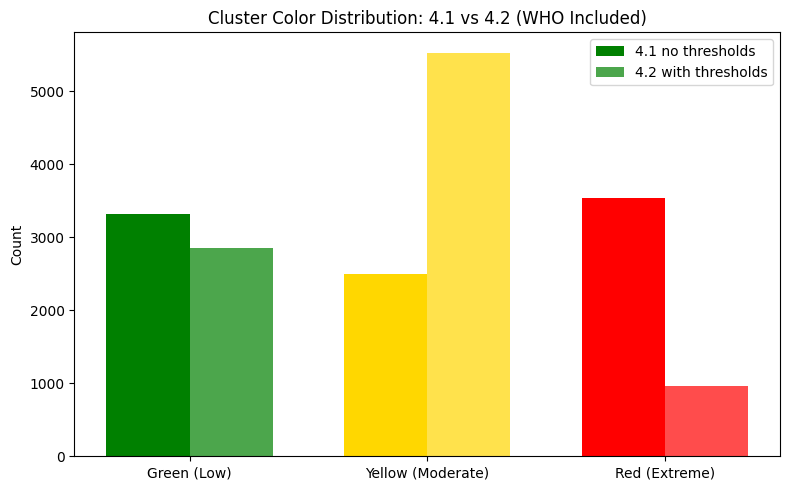

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Data
labels = ['Green (Low)', 'Yellow (Moderate)', 'Red (Extreme)']

data_41 = [3318, 2495, 3544]
data_42 = [2856, 5532, 969]

x = np.arange(len(labels))
width = 0.35

# Plot
plt.figure(figsize=(8,5))
plt.bar(x - width/2, data_41, width, label='4.1 no thresholds', color=['green','gold','red'])
plt.bar(x + width/2, data_42, width, label='4.2 with thresholds', alpha=0.7, color=['green','gold','red'])

# Labels
plt.xticks(x, labels)
plt.ylabel('Count')
plt.title('Cluster Color Distribution: 4.1 vs 4.2 (WHO Included)')
plt.legend()

plt.tight_layout()
plt.show()

### Overall Evaluation

1. The technical success criterion-achieving a Silhouette Score ≥ 0.5 - was not met. Observed scores in the range of 0.23 to 0.28 suggest that the dataset does not naturally form well-separated clusters. Incorporating toxin threshold features provided only a marginal improvement.

2. The business objective, however, was achieved. Despite the lack of strong natural clustering, the data could be effectively partitioned into three groups using k-means for clustering, enabling a practical "traffic light" classification (low, moderate, extreme) for decision-making.

3. Visual inspection of the DBSCAN results further supports these findings. The clustering structure is not clearly distinguishable and even by eye it is difficult to identify more than one meaningful cluster. DBSCAN proved unsuitable for this dataset, as the observations are densely distributed with no clear gaps. Additionally, variables such as temperature, humidity or month do not exert sufficient influence on pollution levels to create distinct density-based clusters.

4. The Cluster-Color-Distribution plot ndicates that incorporating toxin threshold features shifts a substantial portion of data points into the moderate category, reducing the size of the red (extreme) cluster by more than two-thirds.

5. Both clustering approaches consistently indicate that morning hours are the most suitable for outdoor sports, while the period between 1 PM and 4 PM should be avoided due to elevated toxin levels.

6. Surprisingly, the data does not reveal any strong seasonal patterns or significant weather-driven variation in toxin concentrations.

7. The PCA results indicate that the toxin variables themselves have the strongest influence on the clustering. Many pollutants increase simultaneously, highlighting a high degree of multicollinearity in the data.